<a href="https://colab.research.google.com/github/SayanB58/HAAI__Cohort2_LLM_Tokenizers_Embeddings/blob/main/Week_4_Session_2_Hands_on_AgenticAI_with_LangChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

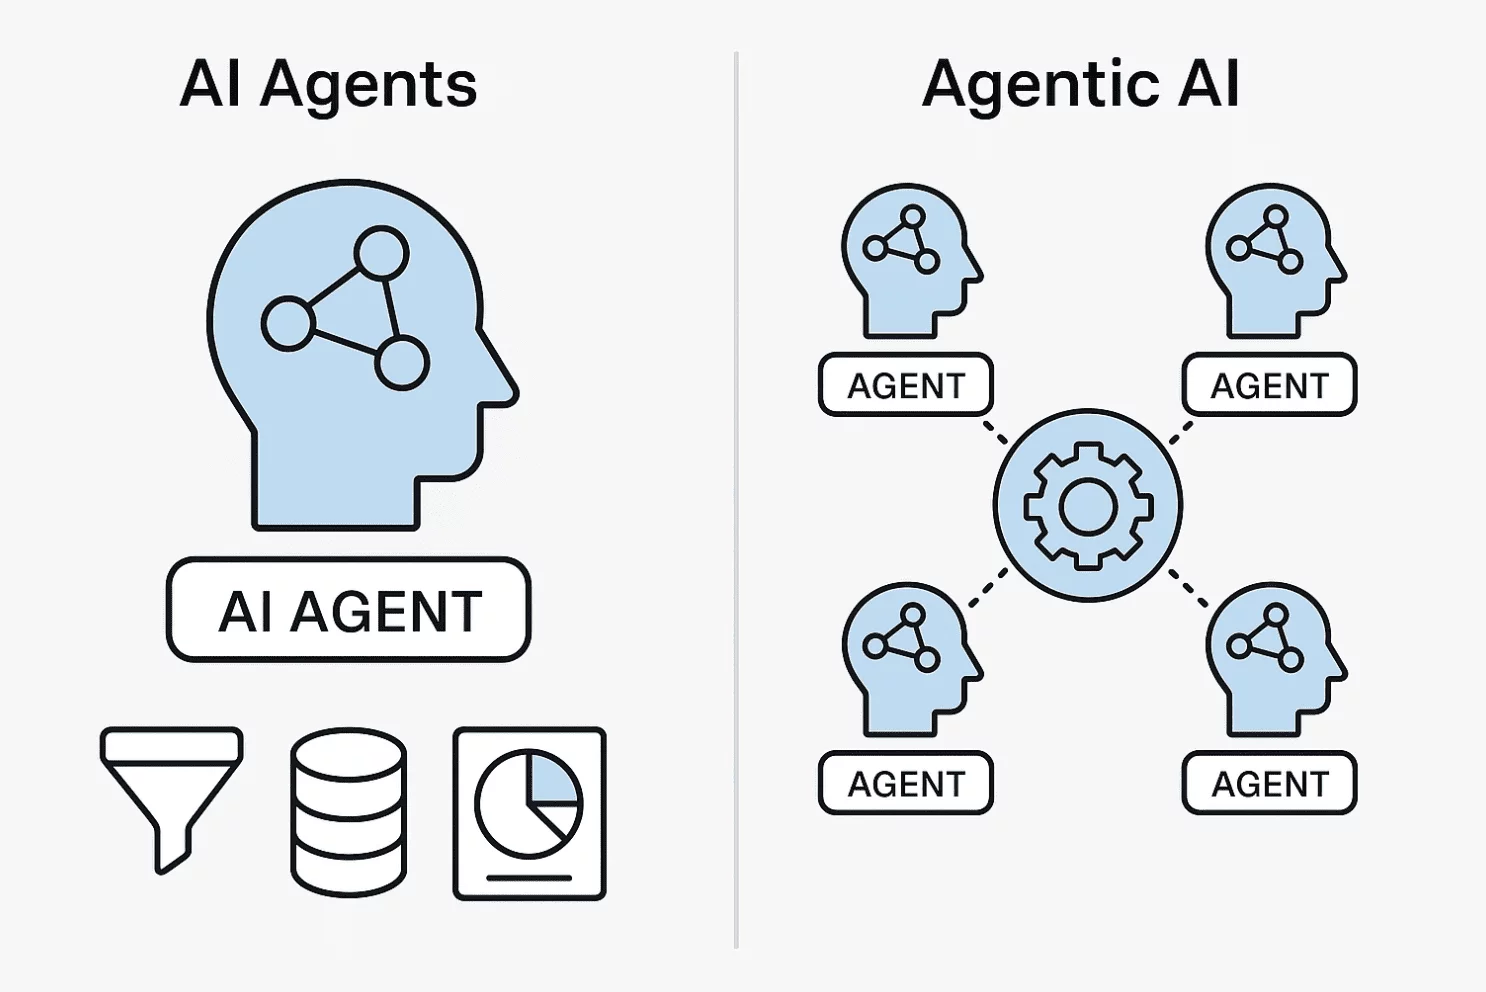

Image Source: https://theaiinsider.tech/2025/05/19/whats-the-difference-between-ai-agents-and-agentic-ai-new-study-separates-signal-from-noise-in-the-ai-agent-boom/

By **Nilanjan Sinhababu**

Types of tools:
1. Websearch - RAG
2. Database Access - Company
3. API Endpoint Access -
4. System-of-Experts

Contents:
1. Create tools
2. Use built-in tools
3. chat tools
4. output parse

# Setup

In [ ]:
# Setup

!pip install langchain
!pip install langchain-core

!pip install --upgrade --quiet  wikipedia
!pip install langchain-community

!pip install -qU duckduckgo-search langchain-community
!pip install -U ddgs

!pip install -U langchain-groq

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB

# Tools in LangChain

## User-defined Tools

In [ ]:
from langchain_core.tools import tool

In [ ]:
# built your first tool with @tool decorator

@tool
def add_tool(a:int, b:int)->int:
    '''Sum of two numbers'''
    return a+b

In [ ]:
print(add_tool.name)
print(add_tool.description)
print(add_tool.args)

add_tool
Sum of two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [ ]:
# async tool
@tool
async def aadd_tool(a:int, b:int)->int:
    '''Async function to add two numbers'''
    return a+b

In [ ]:
from typing import Annotated,List
@tool
def multiply_by_sum_tool(
    a: Annotated[int,'An integer Value'],
    b: Annotated[List[int],'List of integer values']
)->int:
    '''Multiply a by summation of b values'''
    return a*sum(b)

In [ ]:
print(multiply_by_sum_tool.args)

{'a': {'description': 'An integer Value', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'List of integer values', 'items': {'type': 'integer'}, 'title': 'B', 'type': 'array'}}


In [ ]:
a = 3
b = [6,5,3,4,2]
print(multiply_by_sum_tool.invoke({'a':a, 'b':b}))

60


LLM Initialization using LangChain

In [ ]:
# tools = [add_tool, aadd_tool, multiply_by_sum_tool]
tools = [add_tool, multiply_by_sum_tool]

In [ ]:
tools

[StructuredTool(name='add_tool', description='Sum of two numbers', args_schema=<class 'langchain_core.utils.pydantic.add_tool'>, func=<function add_tool at 0x7f5467b6a520>),
 StructuredTool(name='multiply_by_sum_tool', description='Multiply a by summation of b values', args_schema=<class 'langchain_core.utils.pydantic.multiply_by_sum_tool'>, func=<function multiply_by_sum_tool at 0x7f5467b6b7e0>)]

In [ ]:
tools[0].args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [ ]:
tools[1].args

{'a': {'description': 'An integer Value', 'title': 'A', 'type': 'integer'},
 'b': {'description': 'List of integer values',
  'items': {'type': 'integer'},
  'title': 'B',
  'type': 'array'}}

In [ ]:
api_key = ""

In [ ]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("qwen/qwen3-32b", model_provider="groq", api_key=api_key)

In [ ]:
prompt = 'What is 2+3=?, 3+3=? and 2+6=?.'
#prompt = 'What is the output if we need to multiply an integer 2 with sum of this list: [1,2,3,4]?'

In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(prompt)]

In [ ]:
messages

[HumanMessage(content='What is 2+3=?, 3+3=? and 2+6=?.', additional_kwargs={}, response_metadata={})]

In [ ]:
response_llm = llm.invoke(messages)

In [ ]:
response_llm.content

"<think>\nOkay, so I need to figure out these three addition problems: 2+3=?, 3+3=?, and 2+6=?. Let me start with the first one, 2+3. Hmm, addition is about combining numbers. So if I have 2 apples and then get 3 more apples, how many do I have in total? Let me count: 1, 2, then adding 3 more... 3, 4, 5. So 2+3 should be 5. That seems straightforward.\n\nNext up is 3+3. This is adding the same number twice. Three plus three. Let me visualize it. If I have three blocks and another three blocks, putting them together would make six blocks. So 3+3 equals 6. Wait, is there another way to check that? Maybe using fingers. Three fingers on one hand and three on the other... yeah, that's six. Okay, that checks out.\n\nNow the last one: 2+6. So two plus six. Let me think. If I start at 2 and count six more: 3 (1), 4 (2), 5 (3), 6 (4), 7 (5), 8 (6). So starting at 2, adding six gets me to 8. Alternatively, 6 plus 2 is the same as 2 plus 6, and since 6+2 is 8, commutative property and all. Yeah, 


Now consider this LLM has access to the tools that we have.


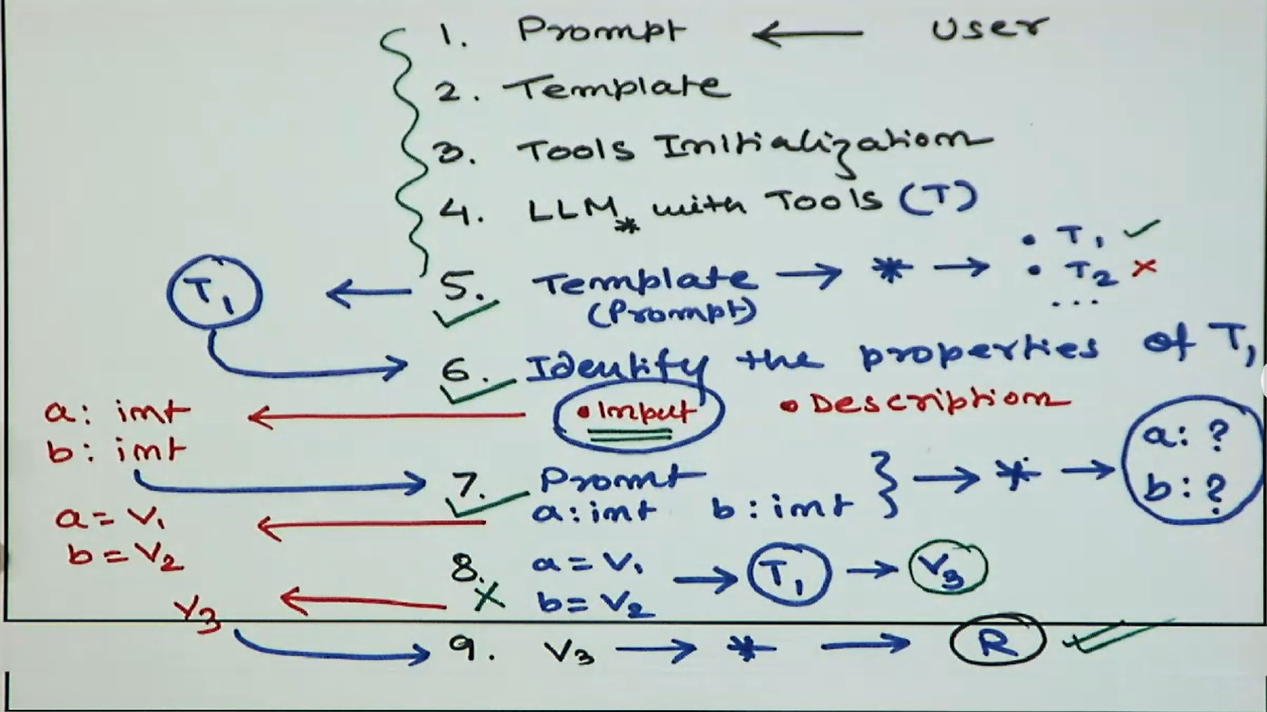

In [ ]:
model = llm.bind_tools(tools)

In [ ]:
def llm_with_tools(messages, tools):
    response = model.invoke(messages)
    tool_start=0
    for tool_call in response.tool_calls:
        tool_name = tool_call['name'].lower()
        for tool in tools:
            if tool.name == tool_name:
                tool_output = tool.invoke(tool_call)
                messages.append(tool_output)
                tool_start=1

    if tool_start==1:
        tool_start=0
        response = llm_with_tools(messages, tools)
    return response

In [ ]:
final_response = llm_with_tools(messages, tools)
print(final_response.content)

The answers are:

- 2 + 3 = **5**  
- 3 + 3 = **6**  
- 2 + 6 = **8**


In [ ]:
final_response

AIMessage(content='The answers are:\n\n- 2 + 3 = **5**  \n- 3 + 3 = **6**  \n- 2 + 6 = **8**', additional_kwargs={'reasoning_content': "Okay, let's see. The user asked three separate addition problems: 2+3, 3+3, and 2+6. I need to handle each of these. Since there's a tool called add_tool that adds two integers, I should use that for each problem.\n\nFirst, for 2+3, I'll call add_tool with a=2 and b=3. The response came back as 5, which makes sense.\n\nNext, 3+3. Using the same tool with a=3 and b=3 gives 6. That's correct.\n\nThen, 2+6. Calling add_tool again with a=2 and b=6 results in 8. All answers check out.\n\nThe user might just be testing basic addition, so providing the correct answers in order should suffice. No need for extra explanation unless they ask for it. Everything looks good here.\n"}, response_metadata={'token_usage': {'completion_tokens': 225, 'prompt_tokens': 295, 'total_tokens': 520, 'completion_time': 0.443332469, 'completion_tokens_details': {'reasoning_tokens'

## Build Custom Prompt Templates

In [ ]:
from langchain_core.tools import StructuredTool

def prompt_maker(template: str, values: List[str]) -> str:
    '''Function to build final prompt from template and return list of prompts for each value.'''
    prompts = [template.format(value=value) for value in values]
    return prompts

async def aprompt_maker(template: str, values: List[str]) -> str:
    '''Async Function to build final prompt from template and return list of prompts for each value.'''
    prompts = [template.format(value=value) for value in values]
    return prompts

prompt_tool = StructuredTool.from_function(func=prompt_maker, coroutine=aprompt_maker)

In [ ]:
template = "Answer the following question in 100 words: {value}"
values = ['Do goldfish grow?','Can cats swim?', 'Difference between hot and cold coffee?']

In [ ]:
print(prompt_tool.invoke({'template':template,'values':values}))

In [ ]:
print(await prompt_tool.ainvoke({'template':template,'values':values}))

## LangChain has this to build custom prompts

In [ ]:
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate.from_template("Answer the following question in 100 words: {value}")

prompt = prompt_template.invoke({"value": 'Do goldfish grow?'})

print(prompt)

## Predefined Tools

In [ ]:
#https://python.langchain.com/docs/integrations/tools/

### Wikipedia

**WARNING : WikipediaQueryRun is currently unavailable**

In [ ]:
#%pip install --upgrade --quiet  wikipedia
# %pip install langchain-community

In [ ]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

/tmp/ipykernel_770/2961514931.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import WikipediaQueryRun


In [ ]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_contain_words_max=50)#doc_contain_chars_max=50

In [ ]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [ ]:
wiki_tool.args

{'query': {'description': 'query to look up on wikipedia',
  'title': 'Query',
  'type': 'string'}}

In [ ]:
# print(wiki_tool.invoke({'query': {'description': 'Do goldfish grow?',  'title': 'Query',  'type': 'string'}}))
# print(wiki_tool.invoke({'description': 'Do goldfish grow?'}))
print(wiki_tool.invoke({"query": "Do goldfish grow?"}))

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import wikipedia

# print(wikipedia.summary("Goldfish", sentences=2))
# print(wikipedia.search("Do goldfish grow?"))

### duckduckgo-search

In [ ]:
#%pip install -qU duckduckgo-search langchain-community
# %pip install -U ddgs

In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

ddgs_tool = DuckDuckGoSearchRun()
ddgs_tool.invoke("Do goldfish grow?")

'1 week ago - In their first weeks of life, the fry grow quickly—an adaptation born of the high risk of being devoured by adult goldfish (or other fish and insects) in their environment. Some highly selectively bred goldfish can no longer breed naturally due to their altered shape. The artificial breeding method called "hand stripping" can assist in breeding, but can harm the fish if not done ... 2 weeks ago - When adding goldfish to a new tank, it is important to place no more than two at a time · . This allows helpful bacteria (which turn ammonia to nitrite and finally to nitrate) to grow. If introduced in too great a number before these bacteria grow, the goldfish will die from breathing in too ... March 3, 2026 - Goldfish in captivity rarely, if ever, reach their maximum potential size. In the wild, goldfish can naturally grow to between 6 and 16 inches long. For optimum health and growth, a single goldfish requires a minimum 20- to 30-gallon tank. April 4, 2026 - Have you ever hea

In [ ]:
from langchain_community.tools import DuckDuckGoSearchResults

ddgs_tool = DuckDuckGoSearchResults()
ddgs_tool.invoke("Do goldfish grow?")

'snippet: 1 week ago - In their first weeks of life, the fry grow quickly—an adaptation born of the high risk of being devoured by adult goldfish (or other fish and insects) in their environment. Some highly selectively bred goldfish can no longer breed naturally due to their altered shape. The artificial breeding method called "hand stripping" can assist in breeding, but can harm the fish if not done ..., title: Goldfish - Wikipedia, link: https://en.wikipedia.org/wiki/Goldfish, snippet: 2 weeks ago - When adding goldfish to a new tank, it is important to place no more than two at a time · . This allows helpful bacteria (which turn ammonia to nitrite and finally to nitrate) to grow. If introduced in too great a number before these bacteria grow, the goldfish will die from breathing in too ..., title: Common goldfish - Wikipedia, link: https://en.wikipedia.org/wiki/Common_goldfish, snippet: March 3, 2026 - Goldfish in captivity rarely, if ever, reach their maximum potential size. In th

In [ ]:
from langchain_community.tools import DuckDuckGoSearchResults
ddgs_tool = DuckDuckGoSearchResults(output_format="list")
ddgs_tool.invoke("Do goldfish grow?")

[{'snippet': 'Jan 27, 2026 · How big should you expect your goldfish to get? We have all the answers, including a growth guide, in our article!',
  'title': 'How Big Does a Goldfish Get? Average Weight & Growth Chart',
  'link': 'https://thevetdesk.com/pet-health-wellness/goldfish/goldfish-size-weight-growth-chart/'},
 {'snippet': 'It’s worth noting that the goldfish’s growth speed and maximum size varies depending on numerous factors. We will assess these in detail in today’s article for a clearer and more accurate picture of the matter. This means that the data in the following table may not represent your actual experience with your goldfish. As you can see, the goldfish’s... See full list on smartaquariumguide.com It’s almost impossible to answer this question conclusively. That’s because too many factors weigh in, based on which the answer will change dramatically. Here are some of them to consider: 1. The goldfish strain– Goldfish fall into 2 major categories, fancy and slim-bodi

In [ ]:
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

wrapper = DuckDuckGoSearchAPIWrapper(max_results=2)
ddgs_tool = DuckDuckGoSearchResults(api_wrapper=wrapper, output_format="list")
ddgs_tool.invoke("Do goldfish grow?")

[{'snippet': 'In this article, we take a closer look at how big goldfish get, along with the factors that affect their growth. How Big Do Goldfish Grow? Image Credit: JuanCarlosPalauDiaz_Shutterstock Goldfish can get anywhere from 2 inches to well over 10 inches in a pond. They can even grow larger in the wild due to the abundance of resources and space.',
  'title': 'How Big Does a Goldfish Get? Average Weight & Growth Chart',
  'link': 'https://thevetdesk.com/pet-health-wellness/goldfish/goldfish-size-weight-growth-chart/'},
 {'snippet': "Have you ever heard the common saying that goldfish only grow to the size of their tank? It's a belief that has circulated among aquarists for generations, often leading to misunderstandings about these beautiful fish. Many new hobbyists wonder, do goldfish grow to their environment, or is there more to their growth than meets the eye?",
  'title': 'Do Goldfish Grow To Their Environment - The Truth About Stunting',
  'link': 'https://aquifarm.com/do

# LLM Initialization using LangChain

In [ ]:
# tools = [add_tool, prompt_tool, wiki_tool, ddgs_tool]
# tools = [add_tool, wiki_tool, ddgs_tool]
tools = [add_tool, ddgs_tool]

In [ ]:
#tools = [{'title':'add_tool', 'description':add_tool},
#         {'title':'prompt_tool', 'description':prompt_tool},
#        {'title':'wiki_tool', 'description':wiki_tool},
#        {'title':'ddgs_tool', 'description':ddgs_tool}]

In [ ]:
tools

[StructuredTool(name='add_tool', description='Sum of two numbers', args_schema=<class 'langchain_core.utils.pydantic.add_tool'>, func=<function add_tool at 0x7f5467b6a520>),
 DuckDuckGoSearchResults(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=2, backend='auto', source='text'), output_format='list')]

In [ ]:
tools[1].args

{'query': {'description': 'search query to look up',
  'title': 'Query',
  'type': 'string'}}

In [ ]:
# https://python.langchain.com/docs/integrations/chat/

#pip install -U langchain-groq
# Get The model API Key
#https://console.groq.com/keys

In [ ]:
#from langchain.chat_models import init_chat_model

llm = init_chat_model("qwen/qwen3-32b", model_provider="groq", api_key=api_key)

In [ ]:
model = llm.bind_tools(tools)

In [ ]:
#prompt = 'What is 2+3?'
prompt = 'What is weather today in Kharagpur?'
#prompt = 'Tell me something about Amhedabad plane crash.'
#prompt = 'Tell me something about the recent Amhedabad plane crash.'

In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(prompt)]

In [ ]:
messages

[HumanMessage(content='What is weather today in Kharagpur?', additional_kwargs={}, response_metadata={})]

In [ ]:
response_llm = model.invoke(messages)

In [ ]:
print(response_llm.additional_kwargs['reasoning_content'])

Okay, the user is asking for the weather in Kharagpur today. Let me see which tool I can use. The available tools are add_tool and duckduckgo_results_json. The add_tool is for adding numbers, which doesn't help here. The duckduckgo_results_json is for searching current events or information. Since weather is something that changes and isn't known in advance, I should use the duckduckgo tool. The query parameter needs to be a string, so I'll input "current weather in Kharagpur" as the search query. That should fetch the latest weather data for them.



In [ ]:
print(response_llm)

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Kharagpur today. Let me see which tool I can use. The available tools are add_tool and duckduckgo_results_json. The add_tool is for adding numbers, which doesn\'t help here. The duckduckgo_results_json is for searching current events or information. Since weather is something that changes and isn\'t known in advance, I should use the duckduckgo tool. The query parameter needs to be a string, so I\'ll input "current weather in Kharagpur" as the search query. That should fetch the latest weather data for them.\n', 'tool_calls': [{'id': 'tajz45bdg', 'function': {'arguments': '{"query":"current weather in Kharagpur"}', 'name': 'duckduckgo_results_json'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 255, 'total_tokens': 413, 'completion_time': 0.3096952, 'completion_tokens_details': {'reasoning_tokens': 125}, 'prompt_time': 0.012128366, 'prom

In [ ]:
response_llm.tool_calls

[{'name': 'duckduckgo_results_json',
  'args': {'query': 'current weather in Kharagpur'},
  'id': 'tajz45bdg',
  'type': 'tool_call'}]

In [ ]:
for tool_call in response_llm.tool_calls:
    tool_name = tool_call['name'].lower()
    for tool in tools:
        if tool.name == tool_name:
            tool_output = tool.invoke(tool_call)
            messages.append(tool_output)

In [ ]:
messages

[HumanMessage(content='What is weather today in Kharagpur?', additional_kwargs={}, response_metadata={}),
 ToolMessage(content='[{"snippet": "Current weather in Kharagpur, West Bengal, India. Check current conditions in Kharagpur, West Bengal, India with radar, hourly, and more.···", "title": "Kharagpur, West Bengal, India Current Weather | AccuWeather", "link": "https://www.accuweather.com/en/in/kharagpur/191582/current-weather/191582"}, {"snippet": "Get the latest hourly weather updates for Kharagpur today. Detailed forecast including temperature, wind, rain, snow, and UV index. Stay informed about today\'s weather conditions in Kharagpur.", "title": "Today\'s Weather in Kharagpur - Hourly Forecast and Conditions", "link": "https://www.easeweather.com/asia/india/west-bengal/paschim-medinipur/kharagpur/today"}, {"snippet": "Kharagpur Weather Forecast. Providing a local hourly Kharagpur weather forecast of rain, sun, wind, humidity and temperature. The Long-range 12 day forecast also i

In [ ]:
response = model.invoke(messages)
print(response.content)

Here's the latest weather information for Kharagpur based on current sources:

1. **Current Conditions**  
   Check [AccuWeather](https://www.accuweather.com/en/in/kharagpur/191582/current-weather/191582) for real-time temperature, humidity, and precipitation details.

2. **Hourly Forecast**  
   Visit [EasyWeather](https://www.easeweather.com/asia/india/west-bengal/paschim-medinipur/kharagpur/today) for hourly updates on rain, wind speed, and UV index.

3. **Extended Forecast**  
   Explore [Weather-Forecast](https://www.weather-forecast.com/locations/Kharagpur-1/forecasts/latest) for temperature trends and weather warnings (e.g., thunderstorms, high winds).

For immediate details like temperature ranges or today’s precipitation chance, refer to these links directly. Let me know if you’d like me to refine the search further!


## Structure the tool-invocation process

In [ ]:
def llm_with_tools(messages, tools):
    response = model.invoke(messages)
    tool_start=0
    for tool_call in response.tool_calls:
        tool_name = tool_call['name'].lower()
        for tool in tools:
            if tool.name == tool_name:
                tool_output = tool.invoke(tool_call)
                messages.append(tool_output)
                tool_start=1

    if tool_start==1:
        tool_start=0
        response = llm_with_tools(messages, tools)
    return response

In [ ]:
messages = [HumanMessage(prompt)]

In [ ]:
messages

In [ ]:
final_response = llm_with_tools(messages, tools)
print(final_response.content)

In [ ]:
print(final_response.tool_calls)

# Memory Integration

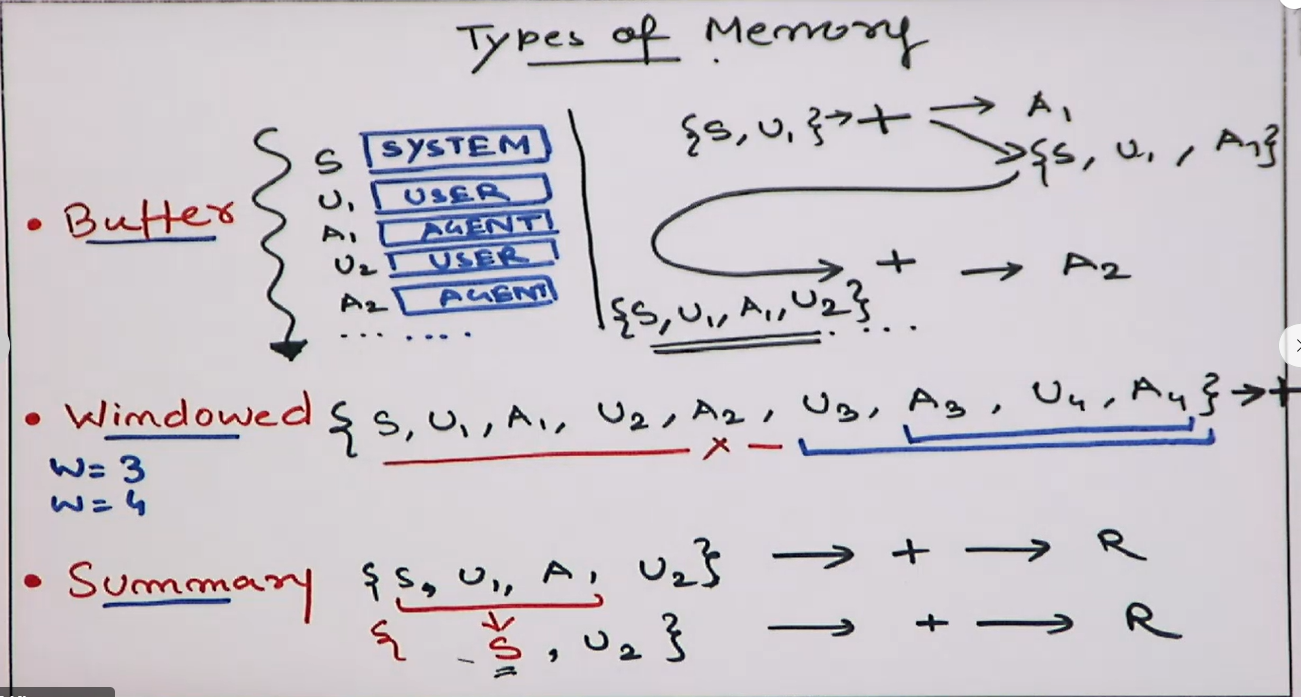

Options of memory

1. Incontext Learning -- Part of the prompt
2. External lookup -- Database

### Conversation Memory and Conversation Chains

In [ ]:
%pip install langchain-classic

In [ ]:
from langchain_classic.chains import ConversationChain
from langchain_classic.memory import ConversationBufferMemory

In [ ]:
# Initialize conversational memory
memory = ConversationBufferMemory()

/tmp/ipykernel_770/1874279983.py:2: LangChainDeprecationWarning: The class `ConversationBufferMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  memory = ConversationBufferMemory()


In [ ]:
# Create the conversation chain with LLM and memory
conversation = ConversationChain(llm=llm, memory=memory, verbose=True)

/tmp/ipykernel_770/201526491.py:2: LangChainDeprecationWarning: The class `ConversationChain` was deprecated in LangChain 0.2.7 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. Build a conversational agent with `langchain.agents.create_agent` and persist message history via a LangGraph checkpointer.
  conversation = ConversationChain(llm=llm, memory=memory, verbose=True)


In [ ]:
# Use the conversation chain
response = conversation.run("Hello, how are you?")
print(response)

/tmp/ipykernel_770/513500309.py:2: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  response = conversation.run("Hello, how are you?")




> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: Hello, how are you?
AI:

> Finished chain.
<think>
Okay, the user said "Hello, how are you?" I need to respond appropriately. Since the AI is talkative and provides specific details, I should make sure the response is friendly and offers assistance. Let me start with a greeting and then ask how I can help. Maybe add an emoji to keep it friendly. Wait, the example shows the AI using an emoji in the response. Let me check the guidelines again. The AI should be helpful and provide specific details. So, the response should be something like, "Hi there! I'm just a stream of consciousness, but I'm here and ready to help. How can I assist you today? 😊" That sounds goo

In [ ]:
response = conversation.run("What is weather today?")
print(response)



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
Human: Hello, how are you?
AI: <think>
Okay, the user said "Hello, how are you?" I need to respond appropriately. Since the AI is talkative and provides specific details, I should make sure the response is friendly and offers assistance. Let me start with a greeting and then ask how I can help. Maybe add an emoji to keep it friendly. Wait, the example shows the AI using an emoji in the response. Let me check the guidelines again. The AI should be helpful and provide specific details. So, the response should be something like, "Hi there! I'm just a stream of consciousness, but I'm here and ready to help. How can I assist you today? 😊" That sounds good. It's friendly, me

In [ ]:
# Memory maintains the conversation history for context
conversation.memory.buffer

'Human: Hello, how are you?\nAI: <think>\nOkay, the user said "Hello, how are you?" I need to respond appropriately. Since the AI is talkative and provides specific details, I should make sure the response is friendly and offers assistance. Let me start with a greeting and then ask how I can help. Maybe add an emoji to keep it friendly. Wait, the example shows the AI using an emoji in the response. Let me check the guidelines again. The AI should be helpful and provide specific details. So, the response should be something like, "Hi there! I\'m just a stream of consciousness, but I\'m here and ready to help. How can I assist you today? 😊" That sounds good. It\'s friendly, mentions the AI\'s nature, and invites the user to ask for help. The emoji adds a friendly touch. I think that\'s in line with the instructions.\n</think>\n\nHi there! I\'m just a stream of consciousness, but I\'m here and ready to help. How can I assist you today? 😊\nHuman: What is weather today?\nAI: <think>\nOkay, 

### Window based memory is benificial to provide full context for last few conversations

In [ ]:
# from langchain.memory import ConversationBufferWindowMemory
from langchain_classic.memory import ConversationBufferWindowMemory

In [ ]:
# Initialize conversational memory
windowed_memory = ConversationBufferWindowMemory()



/tmp/ipykernel_770/2494044796.py:2: LangChainDeprecationWarning: The class `ConversationBufferWindowMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  windowed_memory = ConversationBufferWindowMemory()


In [ ]:
# Create the conversation chain with LLM and memory
windowed_conversation = ConversationChain(llm=llm, memory=windowed_memory, verbose=True)

In [ ]:
# Use the conversation chain
response = windowed_conversation.run("Hello, how are you?")
print(response)



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: Hello, how are you?
AI:

> Finished chain.
<think>
Okay, the user said "Hello, how are you?" which is a common greeting. I need to respond politely. Since I'm an AI, I don't have feelings, but I should acknowledge their greeting and offer help. Maybe add an emoji to keep it friendly. Let me check previous interactions to see the tone. The user wants a talkative AI with lots of details. So I should elaborate a bit. Let me say I'm functioning well, thank them, and ask how I can assist. Keep it open-ended to encourage further conversation.
</think>

Hello! I'm functioning well, thank you for asking. 😊 How can I assist you today? I'm here to chat, answer questions,

### Summary memory helps with lowering context token limitations

In [ ]:
from langchain_classic.memory import ConversationSummaryMemory

In [ ]:
# Initialize summary memory (pass LLM for summarization)
summary_memory = ConversationSummaryMemory(llm=llm)

/tmp/ipykernel_770/2870659218.py:2: LangChainDeprecationWarning: The class `ConversationSummaryMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  summary_memory = ConversationSummaryMemory(llm=llm)


In [ ]:
# Create the conversation chain with LLM and memory
summary_conversation = ConversationChain(llm=llm, memory=summary_memory, verbose=True)

In [ ]:
response = summary_conversation.run("Hi, I am Sayan. Who are you?")
print(response)



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: Hi, I am Sayan. Who are you?
AI:

> Finished chain.
<think>
Okay, the user introduced himself as Sayan and asked who I am. I need to respond appropriately. Let me check the guidelines again. The AI should be talkative and provide specific details from the context. Also, if it doesn't know the answer, it should say so.

First, I should state my name, which is Qwen. Then, mention that I'm a large language model developed by Alibaba Cloud's Tongyi Lab. Highlight my capabilities like answering questions, creating text, and supporting various tasks. Keep it friendly and open-ended to encourage further conversation. Make sure to use emojis to keep the tone approachab

In [ ]:
response = summary_conversation.run("I stay in Kharagpur, India. Do you know about this place?")



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
<think>
Okay, so the user provided a new conversation where the human introduces themselves as Sayan and asks who the AI is. The AI responds with its name, Qwen, and its capabilities. I need to create a summary that combines the current summary (which is empty in this case) with the new lines. The example given shows that the summary should be concise and include the key points from the conversation.

First, the human says, "Hi, I am Sayan. Who are you?" and the AI responds with its name, Qwen, and details about being a large language model developed by Alibaba Cloud's Tongyi Lab. The AI also lists its capabilities like answering questions, creating text, supporting mu

In [ ]:
response = summary_conversation.run("Do you know my name?")



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
<think>
Okay, let me try to work through this step by step. The user wants me to progressively summarize the conversation by adding onto the previous summary. The current summary is the one provided, which is the AI's response about Kharagpur.

First, the new lines of conversation are the AI's detailed answer about Kharagpur, including IIT KGP, the railway station, cultural aspects, etc. I need to take the existing summary and incorporate this new information into it. 

Wait, the example shows that the new summary should include both the previous summary and the new information. But in this case, the previous summary is the AI's response, and the new lines are the same

In [ ]:
response

'<think>\nOkay, let me try to figure out how to approach this. The user just asked, "Do you know my name?" after the AI provided information about Kharagpur.\n\nFirst, I need to recall the conversation history. The human introduced themselves as Sayan initially. The AI then gave a detailed response about Kharagpur. Now, the human is asking if the AI knows their name. \n\nLooking back, the human\'s first message was "Hi, I\'m Sayan." So the AI should remember that the user\'s name is Sayan. The AI\'s previous response included acknowledging the user\'s question about Kharagpur, but the current question is about the user\'s name.\n\nThe AI needs to confirm that it does know the user\'s name, which is Sayan, as provided in the initial interaction. The key here is to reference the user\'s self-introduction and affirm that the AI has retained that information.\n\nI should check if there\'s any step-by-step process needed. The user wants the AI to truthfully state if it doesn\'t know the ans

# Goal Driven Agent: Building an Air Crash Investigator

In [ ]:
query = 'Tell me something about the recent Amhedabad plane crash.'

In [ ]:
#clear the memory to ready for a new conversation
memory = ConversationSummaryMemory(llm=llm)

In [ ]:
conversation = ConversationChain(llm=llm, memory=memory, verbose=True)

In [ ]:
response = conversation.run(query)
print(response)



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: Tell me something about the recent Amhedabad plane crash.
AI:

> Finished chain.
<think>
Okay, the user is asking about the recent Ahmedabad plane crash. Let me start by recalling if there was a recent incident in Ahmedabad. I know that Ahmedabad is a city in India, and there's a major airport there called Sardar Vallabhbhai Patel International Airport. 

First, I need to check the timeline. The user said "recent," so I should look into the past few months. Let me think—the last major plane crash in India... I recall that in 2020, there was a crash in Madhya Pradesh involving a Mi-17 helicopter, but that's not Ahmedabad. Wait, maybe it's a more recent incident.

In [ ]:
# Create the conversation chain with tool supported LLM and memory
tool_conversation = ConversationChain(llm=model, memory=memory, verbose=True)

In [ ]:
# see if tooled model can help
model.invoke(query)

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the recent Ahmedabad plane crash. First, I need to recall if there\'s been a plane crash in Ahmedabad recently. I don\'t think I have that information in my training data, which is up to October 2023. So, I should use the DuckDuckGo search tool to find the latest information.\n\nI should call the duckduckgo_results_json function with the query "recent Ahmedabad plane crash." That should fetch the latest news articles or reports about the incident. Once I get the search results, I can summarize the key details like the date, aircraft involved, casualties, and any official statements or causes mentioned. It\'s important to present the information accurately and concisely, making sure to cite reliable sources if possible. If there are multiple reports, I should cross-check the information to ensure consistency before relaying it to the user.\n', 'tool_calls': [{'id': '0bpdg52kk', 'function': {'ar

In [ ]:
messages = [HumanMessage(query)]
final_response = llm_with_tools(messages, tools)

In [ ]:
import re

def clean_text(text):
    """
    Cleans the given text by:
    - Removing extra whitespace (spaces, tabs, newlines)
    - Stripping leading/trailing whitespace
    - Removing unwanted control characters
    """
    # Strip leading and trailing whitespace
    cleaned = text.strip()
    # Replace newlines, tabs, and multiple spaces with a single space
    cleaned = re.sub(r"\s+", " ", cleaned)
    # Optionally remove non-printable/control characters except basic punctuation
    cleaned = re.sub(r"[^\x20-\x7E]", "", cleaned)
    return cleaned

In [ ]:
response_content = clean_text(final_response.content)
print(response_content)

The most recent information I have regarding an Ahmedabad plane crash refers to an incident involving an Air India Boeing 787 Dreamliner (Flight AI 171) on May 27, 2020. Key details include: - The flight, en route from Ahmedabad to London's Gatwick Airport, crashed shortly after takeoff, killing all 242 passengers and crew. - The plane plummeted into a residential area, sparking a massive emergency response. - The pilot issued a "Mayday" distress call before the crash. - Civil authorities managed a 72-hour operation to recover victims and identify bodies using DNA analysis. This event is often referenced in news archives, but there are no reports of a more recent Ahmedabad plane crash as of my knowledge cutoff in October 2023. If you're referring to a newer incident, please check the latest news for updates.


### In-context Learning

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

prompt_template = ChatPromptTemplate([
    ("system", "You are an Aircrash Investigator."),
    MessagesPlaceholder("msgs")
])

# More complex example with conversation history
messages_to_pass = [
    HumanMessage(content=query),
    AIMessage(content=response_content),
    HumanMessage(content="Provide a clear, detailed report summarizing the findings, probable causes, and recommendations for future safety improvements.")
]

formatted_prompt = prompt_template.invoke({"msgs": messages_to_pass})
print(formatted_prompt)

In [ ]:
#investigator_conversation = ConversationChain(llm=llm, memory=memory, prompt=[chat_prompt], verbose=True)
#clear the memory to ready for a new conversation
memory.clear()
# Initialize the ConversationChain with the custom system prompt only and memory
investigator_conversation = ConversationChain(
    llm=llm,
    memory=memory,
    verbose=True
)

In [ ]:
response = llm.invoke(formatted_prompt.to_messages())

In [ ]:
print(response.content)